# Qwen3.5-0.8B + FlyEmbedding-v3.2
## Token-dependent grouped gating

FlyEmbedding-v3.2 keeps exact Qwen initialization but replaces the single global residual gate with a token-dependent grouped gate.

For each token:

    e' = e_qwen + alpha * gate(e_qwen) * Fly(e_qwen)

The 1024 hidden dimensions are divided into 32 groups by default, so the model can selectively protect or modify different parts of the embedding.

This notebook includes preservation-first training, WikiText validation, gate diagnostics, fast downstream evaluation, speed testing, and optional Hugging Face upload.


In [1]:
#@title 1. Setup
import pathlib, subprocess, sys, importlib, torch, os, shutil, json, time
REPO_DIR=pathlib.Path('/content/TinyCeNN-LM')

if REPO_DIR.exists():
    subprocess.run(['git','-C',str(REPO_DIR),'fetch','origin'],check=True)
    subprocess.run(['git','-C',str(REPO_DIR),'reset','--hard','origin/main'],check=True)
else:
    subprocess.run(['git','clone','https://github.com/vtavakkoli/TinyCeNN-LM.git',str(REPO_DIR)],check=True)

subprocess.run([
    sys.executable,'-m','pip','install','-q','-U',
    'transformers','accelerate','huggingface_hub','safetensors',
    'datasets','pandas','matplotlib','ipywidgets','lm-eval','tabulate'
],check=True)
subprocess.run([sys.executable,'-m','pip','install','-q','-e',str(REPO_DIR)],check=True)

SRC_DIR=REPO_DIR/'src'
if str(SRC_DIR) not in sys.path: sys.path.insert(0,str(SRC_DIR))
for name in list(sys.modules):
    if name=='tinycenn_lm' or name.startswith('tinycenn_lm.'):
        del sys.modules[name]
importlib.invalidate_caches()

for p in [
    REPO_DIR/'scripts'/'run_qwen35_flyembedding_v32.py',
    REPO_DIR/'src'/'tinycenn_lm'/'qwen35_flyembedding_v32.py'
]:
    subprocess.run([sys.executable,'-m','py_compile',str(p)],check=True)

print('✓ FlyEmbedding-v3.2 preflight OK')
print('CUDA:',torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:',torch.cuda.get_device_name(0))
else:
    print('⚠️ Switch Colab to GPU runtime.')


✓ FlyEmbedding-v3.2 preflight OK
CUDA: True
GPU: Tesla T4


In [2]:
#@title 2. Configuration
BASE_MODEL='Qwen/Qwen3.5-0.8B' #@param {type:'string'}
RUN_MODE='quick' #@param ['quick','strong']
SEQ_LEN=128 #@param {type:'integer'}

FLY_NODES=256 #@param {type:'integer'}
GRAPH_STEPS=1 #@param {type:'integer'}
GRAPH_MIX_INIT=0.05 #@param {type:'number'}
MAX_RESIDUAL_SCALE=0.05 #@param {type:'number'}

GATE_GROUPS=32 #@param {type:'integer'}
GATE_HIDDEN=64 #@param {type:'integer'}

LR_CORE=0.00015 #@param {type:'number'}
LR_GATE=0.00030 #@param {type:'number'}

PROBE_EVERY=25 #@param {type:'integer'}
MIN_TOP1=0.99 #@param {type:'number'}
MAX_KL=0.005 #@param {type:'number'}
MAX_EMBEDDING_MSE=0.001 #@param {type:'number'}
EARLY_STOP_TOP1=0.985 #@param {type:'number'}
EARLY_STOP_KL=0.0075 #@param {type:'number'}

FAST_EVAL_LIMIT=50 #@param {type:'integer'}
RUN_BASELINE_EVAL=True #@param {type:'boolean'}

HF_REPO_ID='vtava/Qwen35-0.8B-FlyEmbedding-v32' #@param {type:'string'}
UPLOAD_TO_HF=False #@param {type:'boolean'}

OUTPUT_DIR=REPO_DIR/'results'/'flyembedding_v32_qwen35_08b'
STANDALONE_DIR=REPO_DIR/'results'/'Qwen35-0.8B-FlyEmbedding-v32-standalone'
EVAL_DIR=REPO_DIR/'results'/'flyembedding_v32_fast_eval'

print('Gate groups:',GATE_GROUPS,'group width:',1024//GATE_GROUPS)
print('HF target:',HF_REPO_ID)


Gate groups: 32 group width: 32
HF target: vtava/Qwen35-0.8B-FlyEmbedding-v32


In [3]:
#@title 3. Train FlyEmbedding-v3.2
cmd=[
    sys.executable,'-u',str(REPO_DIR/'scripts'/'run_qwen35_flyembedding_v32.py'),
    '--base-model',BASE_MODEL,
    '--run-mode',RUN_MODE,
    '--seq-len',str(SEQ_LEN),
    '--fly-nodes',str(FLY_NODES),
    '--graph-steps',str(GRAPH_STEPS),
    '--graph-mix-init',str(GRAPH_MIX_INIT),
    '--max-residual-scale',str(MAX_RESIDUAL_SCALE),
    '--gate-groups',str(GATE_GROUPS),
    '--gate-hidden',str(GATE_HIDDEN),
    '--lr-core',str(LR_CORE),
    '--lr-gate',str(LR_GATE),
    '--probe-every',str(PROBE_EVERY),
    '--min-top1',str(MIN_TOP1),
    '--max-kl',str(MAX_KL),
    '--max-embedding-mse',str(MAX_EMBEDDING_MSE),
    '--early-stop-top1',str(EARLY_STOP_TOP1),
    '--early-stop-kl',str(EARLY_STOP_KL),
    '--output-dir',str(OUTPUT_DIR)
]
print('='*110); print(' '.join(cmd)); print('='*110)
p=subprocess.Popen(cmd,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True,bufsize=1)
for line in iter(p.stdout.readline,''):
    print(line,end='',flush=True)
rc=p.wait()
print('\nFinished, exit code',rc)
if rc: raise subprocess.CalledProcessError(rc,cmd)

report=json.loads((OUTPUT_DIR/'report.json').read_text())
print('Selected step:',report['selected_step'])
print('Data source:',report['data_source'])
print('Final probe:',json.dumps(report['final_probe'],indent=2))
print('Gate design:',json.dumps(report['gate_design'],indent=2))
print('Quality gate:',report['quality_gate_passed'])


/usr/bin/python3 -u /content/TinyCeNN-LM/scripts/run_qwen35_flyembedding_v32.py --base-model Qwen/Qwen3.5-0.8B --run-mode quick --seq-len 128 --fly-nodes 256 --graph-steps 1 --graph-mix-init 0.05 --max-residual-scale 0.05 --gate-groups 32 --gate-hidden 64 --lr-core 0.00015 --lr-gate 0.0003 --probe-every 25 --min-top1 0.99 --max-kl 0.005 --max-embedding-mse 0.001 --early-stop-top1 0.985 --early-stop-kl 0.0075 --output-dir /content/TinyCeNN-LM/results/flyembedding_v32_qwen35_08b
DEVICE cuda | dtype torch.bfloat16
Loading Qwen teacher...

Loading weights: 100%|██████████| 320/320 [00:00<00:00, 8687.96it/s]
Loading Qwen + FlyEmbedding-v3.2 student...

Loading weights: 100%|██████████| 320/320 [00:00<00:00, 4840.01it/s]
IDENTITY CHECK {"exact_identity": true, "max_abs_embedding_error": 0.0}

Generating test split: 100%|██████████| 4358/4358 [00:00<00:00, 128239.72 examples/s]

Generating train split: 100%|██████████| 36718/36718 [00:00<00:00, 662134.19 examples/s]

Generating validation spl

,step,teacher_ce,student_ce,ce_gap,teacher_kl,embedding_relative_mse,top1_logit_agreement,max_abs_logit_error,eligible
0,0,3.893485,3.893485,0.000000,-2.075080e-09,0.000000e+00,1.000000,0.00000,True
1,25,3.893485,3.893436,-0.000049,7.785294e-06,7.308146e-18,0.999674,0.25000,True
2,50,3.893485,3.893835,0.000350,4.441698e-04,1.048140e-15,0.991536,0.46875,True
3,75,3.893485,3.892548,-0.000936,6.912734e-04,2.098147e-11,0.986654,0.65625,False
4,100,3.893485,3.893130,-0.000355,7.307814e-04,3.809572e-08,0.984701,0.68750,False


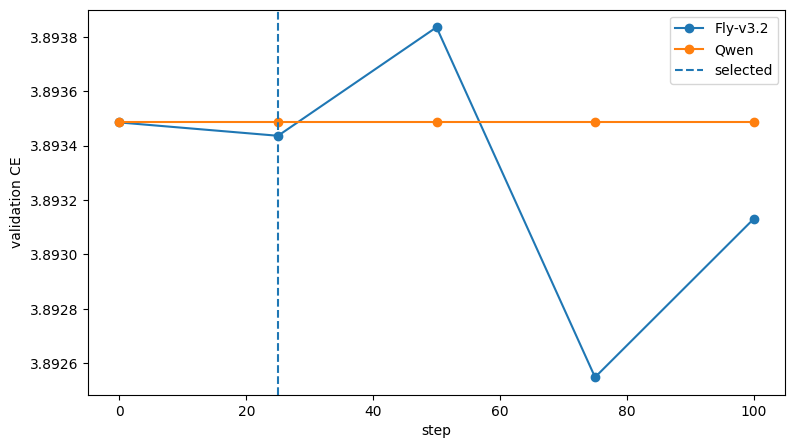

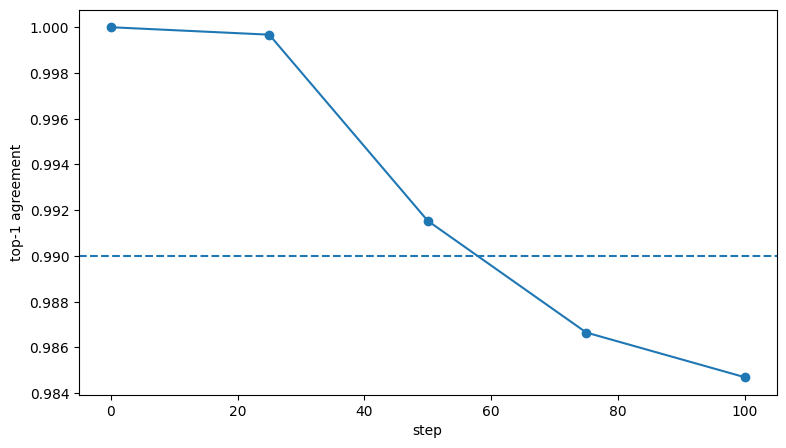

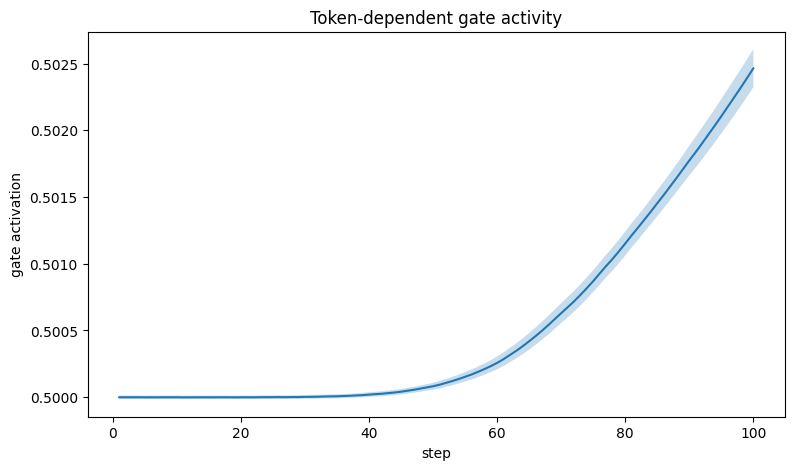

Last gate stats:


,update,gate_mean,gate_std,gate_min,gate_max,residual_scale
80,81,0.501213,0.000091,0.500942,0.501428,0.001404
81,82,0.501271,0.000092,0.500997,0.501487,0.001431
82,83,0.501331,0.000092,0.501065,0.501537,0.001459
83,84,0.501391,0.000095,0.501114,0.501580,0.001487
84,85,0.501454,0.000097,0.501166,0.501650,0.001515
85,86,0.501515,0.000099,0.501216,0.501718,0.001543
86,87,0.501578,0.000101,0.501280,0.501787,0.001572
87,88,0.501642,0.000104,0.501327,0.501854,0.001601
88,89,0.501708,0.000107,0.501388,0.501920,0.001631
89,90,0.501774,0.000112,0.501428,0.501990,0.001660


In [4]:
#@title 4. Training and gate diagnostics
import pandas as pd, matplotlib.pyplot as plt
from IPython.display import display

hist=pd.read_csv(OUTPUT_DIR/'training_history.csv')
probes=pd.read_csv(OUTPUT_DIR/'validation_probes.csv')
display(probes)

plt.figure(figsize=(9,5))
plt.plot(probes['step'],probes['student_ce'],marker='o',label='Fly-v3.2')
plt.plot(probes['step'],probes['teacher_ce'],marker='o',label='Qwen')
plt.axvline(report['selected_step'],linestyle='--',label='selected')
plt.xlabel('step'); plt.ylabel('validation CE'); plt.legend(); plt.show()

plt.figure(figsize=(9,5))
plt.plot(probes['step'],probes['top1_logit_agreement'],marker='o')
plt.axhline(MIN_TOP1,linestyle='--')
plt.xlabel('step'); plt.ylabel('top-1 agreement'); plt.show()

plt.figure(figsize=(9,5))
plt.plot(hist['update'],hist['gate_mean'],label='gate mean')
plt.fill_between(hist['update'],
                 hist['gate_mean']-hist['gate_std'],
                 hist['gate_mean']+hist['gate_std'],alpha=0.25)
plt.xlabel('step'); plt.ylabel('gate activation')
plt.title('Token-dependent gate activity'); plt.show()

print('Last gate stats:')
display(hist[['update','gate_mean','gate_std','gate_min','gate_max','residual_scale']].tail(20))


In [5]:
#@title 5. Generation comparison
for i,x in enumerate(report['generation_samples'],1):
    print('\n'+'='*100)
    print(i,'USER:',x['prompt'])
    print('\nQWEN:',x['qwen_reply'])
    print('\nFLY-v3.2:',x['fly_reply'])
    print('\nexact=',x['exact_token_match'],
          '| prefix=',x['matching_prefix_tokens'],
          '| jaccard=',round(x['token_jaccard'],3),
          '| passed=',x['passed'])



1 USER: Explain in two sentences why the sky is blue.

QWEN: The sky appears blue because sunlight scatters off the Earth's atmosphere, with shorter wavelengths of blue light being scattered more effectively than longer wavelengths like red and orange.

FLY-v3.2: The sky appears blue because sunlight scatters off the Earth's atmosphere, with shorter wavelengths of blue light being scattered more effectively than longer wavelengths like red and orange.

exact= True | prefix= 35 | jaccard= 1.0 | passed= True

2 USER: What is 17 + 25? Give only the answer.

QWEN: 42

FLY-v3.2: 42

exact= True | prefix= 5 | jaccard= 1.0 | passed= True

3 USER: Write one short sentence about Vienna.

QWEN: Vienna is a historic city known for its rich culture, vibrant nightlife, and stunning architecture.

FLY-v3.2: Vienna is a historic city known for its rich culture, vibrant nightlife, and stunning architecture.

exact= True | prefix= 22 | jaccard= 1.0 | passed= True

4 USER: In one sentence, explain what

In [6]:
#@title 6. Materialize to standard Hugging Face checkpoint
from transformers import AutoModelForCausalLM, AutoTokenizer
from tinycenn_lm.qwen35_flyembedding_v32 import (
    FlyEmbeddingV32Config, install_fly_embedding_v32, materialize_fly_embedding_v32
)

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype=torch.bfloat16 if device.type=='cuda' and torch.cuda.is_bf16_supported() else (torch.float16 if device.type=='cuda' else torch.float32)

tok=AutoTokenizer.from_pretrained(BASE_MODEL,use_fast=True)
if tok.pad_token_id is None: tok.pad_token=tok.eos_token

model=AutoModelForCausalLM.from_pretrained(BASE_MODEL,dtype=dtype,low_cpu_mem_usage=True).to(device).eval()

def make_adj(n):
    a=torch.zeros(n,n,dtype=torch.float32)
    for i in range(n):
        a[i,i]=1
        for s in (1,3,7,17):
            a[i,(i+s)%n]=1
            a[i,(i-s)%n]=1
    return (a/a.sum(-1,keepdim=True).clamp_min(1)).to(device)

ckpt=torch.load(OUTPUT_DIR/'fly_embedding_v32_adapter.pt',map_location='cpu')
cfg=FlyEmbeddingV32Config(**ckpt['config'])
install_fly_embedding_v32(model,cfg,make_adj(cfg.fly_nodes))
model.fly_embedding_v32_core.load_state_dict(ckpt['fly_embedding_v32_core'],strict=True)
model.eval()

def gen_ids(m,prompt,max_new_tokens=64):
    text=tok.apply_chat_template([{'role':'user','content':prompt}],tokenize=False,add_generation_prompt=True)
    enc=tok(text,return_tensors='pt').to(device)
    with torch.no_grad():
        out=m.generate(**enc,max_new_tokens=max_new_tokens,do_sample=False,use_cache=True,pad_token_id=tok.eos_token_id)
    ids=out[0,enc.input_ids.shape[1]:]
    return ids.tolist(),tok.decode(ids,skip_special_tokens=True).strip()

checks=['What is 17 + 25? Give only the answer.','Write one short sentence about Vienna.']
before={p:gen_ids(model,p) for p in checks}
materialize_fly_embedding_v32(model,chunk_rows=4096)
after={p:gen_ids(model,p) for p in checks}
for p in checks:
    assert before[p][0]==after[p][0]
    print(p,'->',after[p][1])

if STANDALONE_DIR.exists(): shutil.rmtree(STANDALONE_DIR)
STANDALONE_DIR.mkdir(parents=True,exist_ok=True)
model.save_pretrained(STANDALONE_DIR,safe_serialization=True,max_shard_size='2GB')
tok.save_pretrained(STANDALONE_DIR)
shutil.copy2(OUTPUT_DIR/'report.json',STANDALONE_DIR/'flyembedding_v32_report.json')
shutil.copy2(OUTPUT_DIR/'fly_embedding_v32_adapter.pt',STANDALONE_DIR/'fly_embedding_v32_adapter.pt')
print('✓ Standalone model saved:',STANDALONE_DIR)

del model
if torch.cuda.is_available(): torch.cuda.empty_cache()


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.
[transformers] `causal_conv1d_update` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `fused_recurrent_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.


What is 17 + 25? Give only the answer. -> 42
Write one short sentence about Vienna. -> Vienna is a historic city known for its rich culture, vibrant nightlife, and stunning architecture.


Writing model shards:   0%|          | 0/2 [00:00<?, ?it/s]

✓ Standalone model saved: /content/TinyCeNN-LM/results/Qwen35-0.8B-FlyEmbedding-v32-standalone


In [7]:
#@title 7. FastEval: Qwen vs Fly-v3.2
TASKS='hellaswag,piqa,arc_easy,arc_challenge,winogrande,gsm8k'
if EVAL_DIR.exists(): shutil.rmtree(EVAL_DIR)
EVAL_DIR.mkdir(parents=True,exist_ok=True)

def run_eval(label,pretrained):
    out=EVAL_DIR/label
    out.mkdir(parents=True,exist_ok=True)
    dtype_name='bfloat16' if dtype==torch.bfloat16 else ('float16' if dtype==torch.float16 else 'float32')
    cmd=[
        sys.executable,'-m','lm_eval','--model','hf',
        '--model_args',f'pretrained={pretrained},dtype={dtype_name},trust_remote_code=True',
        '--tasks',TASKS,'--batch_size','auto','--limit',str(FAST_EVAL_LIMIT),
        '--output_path',str(out)
    ]
    print('\n',label,':',' '.join(cmd))
    subprocess.run(cmd,check=False)

run_eval('fly_v32',str(STANDALONE_DIR))
if RUN_BASELINE_EVAL: run_eval('qwen_base',BASE_MODEL)

def newest_result(folder):
    xs=[]
    for p in pathlib.Path(folder).rglob('*.json'):
        try:
            d=json.loads(p.read_text())
            if isinstance(d,dict) and 'results' in d: xs.append((p.stat().st_mtime,d))
        except: pass
    return max(xs,key=lambda x:x[0])[1] if xs else None

fly_eval=newest_result(EVAL_DIR/'fly_v32')
base_eval=newest_result(EVAL_DIR/'qwen_base') if RUN_BASELINE_EVAL else None

def metric(task,d):
    r=(d or {}).get('results',{}).get(task,{})
    for k in ['acc_norm,none','acc,none','exact_match,strict-match','exact_match,flexible-extract']:
        if k in r:return float(r[k]),k
    return None,None

rows=[]
for task in TASKS.split(','):
    fv,fk=metric(task,fly_eval); bv,bk=metric(task,base_eval)
    rows.append({'task':task,'metric':fk or bk,'Qwen':bv,'Fly-v3.2':fv,
                 'delta':(fv-bv) if fv is not None and bv is not None else None})
bench_df=pd.DataFrame(rows)
display(bench_df)
bench_df.to_csv(STANDALONE_DIR/'fast_eval_comparison.csv',index=False)



 fly_v32 : /usr/bin/python3 -m lm_eval --model hf --model_args pretrained=/content/TinyCeNN-LM/results/Qwen35-0.8B-FlyEmbedding-v32-standalone,dtype=bfloat16,trust_remote_code=True --tasks hellaswag,piqa,arc_easy,arc_challenge,winogrande,gsm8k --batch_size auto --limit 50 --output_path /content/TinyCeNN-LM/results/flyembedding_v32_fast_eval/fly_v32

 qwen_base : /usr/bin/python3 -m lm_eval --model hf --model_args pretrained=Qwen/Qwen3.5-0.8B,dtype=bfloat16,trust_remote_code=True --tasks hellaswag,piqa,arc_easy,arc_challenge,winogrande,gsm8k --batch_size auto --limit 50 --output_path /content/TinyCeNN-LM/results/flyembedding_v32_fast_eval/qwen_base


,task,metric,Qwen,Fly-v3.2,delta
0,hellaswag,"acc_norm,none",0.54,0.54,0.0
1,piqa,"acc_norm,none",0.66,0.66,0.0
2,arc_easy,"acc_norm,none",0.68,0.68,0.0
3,arc_challenge,"acc_norm,none",0.36,0.36,0.0
4,winogrande,"acc,none",0.66,0.66,0.0
5,gsm8k,"exact_match,strict-match",0.46,0.46,0.0


In [8]:
#@title 8. Optional Hugging Face upload
if UPLOAD_TO_HF:
    from huggingface_hub import HfApi, notebook_login
    api=HfApi()
    try:
        who=api.whoami()
        print('Logged in as',who.get('name',who))
    except Exception:
        notebook_login()
        api=HfApi()

    readme=f"""---
base_model: {BASE_MODEL}
library_name: transformers
pipeline_tag: text-generation
tags:
- qwen
- flyembedding
- tinycenn
- residual-adapter
---

# Qwen3.5-0.8B FlyEmbedding-v3.2

FlyEmbedding-v3.2 uses token-dependent grouped gating over an identity-preserving Fly residual.

Selected step: {report.get('selected_step')}
Data source: {report.get('data_source')}
Top-1 agreement: {report['final_probe']['top1_logit_agreement']:.6f}
KL to Qwen: {report['final_probe']['teacher_kl']:.6f}
Validation CE gap: {report['final_probe']['ce_gap']:.6f}

## FastEval

{bench_df.to_markdown(index=False)}

Project: https://github.com/vtavakkoli/TinyCeNN-LM
"""
    (STANDALONE_DIR/'README.md').write_text(readme,encoding='utf-8')
    api.create_repo(repo_id=HF_REPO_ID,repo_type='model',exist_ok=True)
    api.upload_folder(folder_path=str(STANDALONE_DIR),repo_id=HF_REPO_ID,repo_type='model',
                      commit_message='Upload FlyEmbedding-v3.2 standalone model')
    print('Uploaded: https://huggingface.co/'+HF_REPO_ID)
else:
    print('UPLOAD_TO_HF=False — model remains local in Colab.')


UPLOAD_TO_HF=False — model remains local in Colab.
